In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

df = pd.read_csv("synthetic_ecommerce_sales_2025.csv")
print(df.head())


   order_id                           customer_id product_category  \
0         1  bdd640fb-0667-4ad1-9c80-317fa3b1799d           Beauty   
1         2  23b8c1e9-3924-46de-beb1-3b9046685257          Fashion   
2         3  bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9           Beauty   
3         4  972a8469-1641-4f82-8b9d-2434e465e150      Electronics   
4         5  17fc695a-07a0-4a6e-8822-e8f36c031199          Fashion   

   product_price  quantity  order_date         region payment_method  \
0         190.40         5  2023-02-21         Europe   BankTransfer   
1          82.22         3  2023-10-13  North America     CreditCard   
2          15.19         2  2023-06-28        Oceania           Cash   
3         310.65         2  2023-07-11         Europe         PayPal   
4          74.05         4  2023-02-24         Africa         PayPal   

   delivery_days  is_returned  customer_rating  discount_percent  revenue  
0              8            0              3.8                 0   952

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   order_id          100000 non-null  int64  
 1   customer_id       100000 non-null  str    
 2   product_category  100000 non-null  str    
 3   product_price     100000 non-null  float64
 4   quantity          100000 non-null  int64  
 5   order_date        100000 non-null  str    
 6   region            100000 non-null  str    
 7   payment_method    100000 non-null  str    
 8   delivery_days     100000 non-null  int64  
 9   is_returned       100000 non-null  int64  
 10  customer_rating   100000 non-null  float64
 11  discount_percent  100000 non-null  int64  
 12  revenue           100000 non-null  float64
dtypes: float64(3), int64(5), str(5)
memory usage: 9.9 MB


In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
order_id,100000.0,50000.500000,28867.657797,1.000,25000.7500,50000.50,75000.250,100000.00
product_price,100000.0,250.962504,141.743414,4.518,128.3875,251.43,372.270,500.00
quantity,100000.0,3.085480,1.438706,1.000,2.0000,3.00,4.000,6.00
delivery_days,100000.0,4.984620,2.579517,1.000,3.0000,5.00,7.000,9.00
is_returned,100000.0,0.060600,0.238596,0.000,0.0000,0.00,0.000,1.00
customer_rating,100000.0,3.500493,0.867731,2.000,2.8000,3.50,4.200,5.00
discount_percent,100000.0,5.014700,6.138865,0.000,0.0000,0.00,10.000,20.00
revenue,100000.0,734.148001,571.191290,4.260,274.1100,585.55,1089.855,2699.14


In [7]:
df.isnull().sum()

order_id            0
customer_id         0
product_category    0
product_price       0
quantity            0
order_date          0
region              0
payment_method      0
delivery_days       0
is_returned         0
customer_rating     0
discount_percent    0
revenue             0
dtype: int64

/var/folders/46/tx0_2b790hx5jt5ww66hfhc00000gn/T/ipykernel_52324/4123558988.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_returned', data=df, palette=['blue', 'orange'])


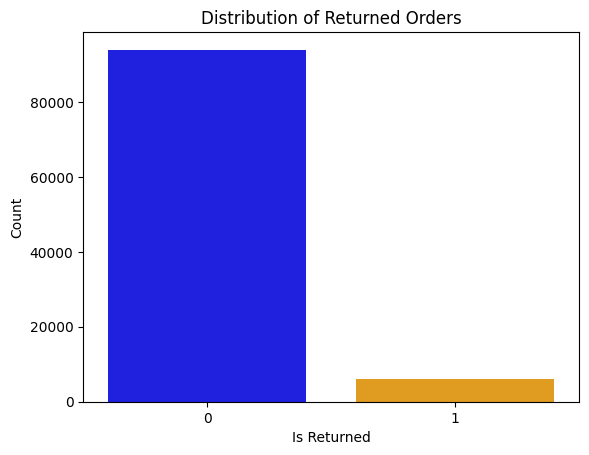

In [10]:
sns.countplot(x='is_returned', data=df, palette=['blue', 'orange'])
plt.title('Distribution of Returned Orders')
plt.xlabel('Is Returned')
plt.ylabel('Count')
plt.show()

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
print("Target distribution - counts:")
display(df["is_returned"].value_counts())

print("\nTarget distribution - percentage:")
display(df["is_returned"].value_counts(normalize=True) * 100)

print("\nUnique values in categorical columns:")
categorical_cols = ["product_category", "region", "payment_method"]

for col in categorical_cols:
    print(f"\n{col}")
    print("Unique values:", df[col].nunique())
    display(df[col].value_counts())

print("\nReturn rate by product category:")
display(df.groupby("product_category")["is_returned"].mean().sort_values(ascending=False) * 100)

print("\nReturn rate by region:")
display(df.groupby("region")["is_returned"].mean().sort_values(ascending=False) * 100)

print("\nReturn rate by payment method:")
display(df.groupby("payment_method")["is_returned"].mean().sort_values(ascending=False) * 100)

Target distribution - counts:


is_returned
0    93940
1     6060
Name: count, dtype: int64


Target distribution - percentage:


is_returned
0    93.94
1     6.06
Name: proportion, dtype: float64


Unique values in categorical columns:

product_category
Unique values: 7


...

product_category
Fashion        12.165841
Automotive      5.274247
Electronics     5.126957
Home            5.105063
Sports          5.050857
Toys            4.898873
Beauty          4.777294
Name: is_returned, dtype: float64


Return rate by region:


region
Oceania          6.283525
North America    6.173503
Europe           6.067946
Asia             6.060968
South America    6.014493
Africa           5.750760
Name: is_returned, dtype: float64


Return rate by payment method:


payment_method
Cash            6.171590
PayPal          6.083650
BankTransfer    6.012040
CreditCard      5.974943
Name: is_returned, dtype: float64

In [13]:
numeric_cols = [
    "product_price",
    "quantity",
    "delivery_days",
    "customer_rating",
    "discount_percent",
    "revenue"
]

print("Numerical feature summary by return status:")
display(
    df.groupby("is_returned")[numeric_cols]
    .agg(["mean", "median", "std", "min", "max"])
    .T
)

print("\nCorrelation of numerical features with is_returned:")
display(
    df[numeric_cols + ["is_returned"]]
    .corr(numeric_only=True)["is_returned"]
    .sort_values(ascending=False)
)

print("\nOrder date range:")
df["order_date"] = pd.to_datetime(df["order_date"])

print("Minimum order date:", df["order_date"].min())
print("Maximum order date:", df["order_date"].max())

print("\nReturn rate by order month:")
monthly_return_rate = (
    df.assign(order_month=df["order_date"].dt.month)
    .groupby("order_month")["is_returned"]
    .mean()
    .sort_index() * 100
)

display(monthly_return_rate)

Numerical feature summary by return status:


is_returned                        0            1
product_price    mean     251.150778   248.043937
                 median   251.610000   248.630000
                 std      141.722851   142.041597
                 min        4.518000     4.644000
                 max      500.000000   499.970000
quantity         mean       3.085363     3.087294
                 median     3.000000     3.000000
                 std        1.438353     1.444285
                 min        1.000000     1.000000
                 max        6.000000     6.000000
delivery_days    mean       4.988397     4.926073
                 median     5.000000     5.000000
                 std        2.580895     2.557569
                 min        1.000000     1.000000
                 max        9.000000     9.000000
customer_rating  mean       3.499884     3.509934
                 median     3.500000     3.500000
                 std        0.867501     0.871308
                 min        2.000000     2.000000
                 max        5.000000     5.000000
discount_percent mean       5.016819     4.981848
                 median     0.000000     0.000000
                 std        6.142479     6.082966
                 min        0.000000     0.000000
                 max       20.000000    20.000000
revenue          mean     734.582684   727.409695
                 median   586.250000   569.005000
                 std      571.053856   573.322650
                 min        4.260000     4.840000
                 max     2699.140000  2690.600000


Correlation of numerical features with is_returned:


is_returned         1.000000
customer_rating     0.002763
quantity            0.000320
discount_percent   -0.001359
revenue            -0.002996
product_price      -0.005230
delivery_days      -0.005765
Name: is_returned, dtype: float64


Order date range:
Minimum order date: 2023-01-01 00:00:00
Maximum order date: 2025-12-31 00:00:00

Return rate by order month:


order_month
1     5.950141
2     6.099161
3     5.700403
4     6.129468
5     6.013806
6     6.297779
7     5.960186
8     5.874826
9     5.796573
10    6.237472
11    6.157547
12    6.509712
Name: is_returned, dtype: float64

In [14]:
# Create a copy before cleaning
df_model = df.copy()

# Convert order_date into date-based features
df_model["order_date"] = pd.to_datetime(df_model["order_date"])

df_model["order_year"] = df_model["order_date"].dt.year
df_model["order_month"] = df_model["order_date"].dt.month
df_model["order_day_of_week"] = df_model["order_date"].dt.dayofweek

# Drop columns that should not be used directly for prediction
columns_to_drop = [
    "order_id",
    "customer_id",
    "order_date",
    "revenue"
]

df_model = df_model.drop(columns=columns_to_drop)

print("Cleaned modeling dataset shape:")
print(df_model.shape)

print("\nColumns used for modeling:")
print(df_model.columns.tolist())

print("\nFirst 5 rows:")
display(df_model.head())

print("\nData types:")
display(df_model.dtypes)

print("\nTarget distribution:")
display(df_model["is_returned"].value_counts(normalize=True) * 100)

Cleaned modeling dataset shape:
(100000, 12)

Columns used for modeling:
['product_category', 'product_price', 'quantity', 'region', 'payment_method', 'delivery_days', 'is_returned', 'customer_rating', 'discount_percent', 'order_year', 'order_month', 'order_day_of_week']

First 5 rows:


,product_category,product_price,quantity,region,payment_method,delivery_days,is_returned,customer_rating,discount_percent,order_year,order_month,order_day_of_week
0,Beauty,190.40,5,Europe,BankTransfer,8,0,3.8,0,2023,2,1
1,Fashion,82.22,3,North America,CreditCard,5,0,3.8,0,2023,10,4
2,Beauty,15.19,2,Oceania,Cash,6,1,2.0,10,2023,6,2
3,Electronics,310.65,2,Europe,PayPal,9,0,2.9,5,2023,7,1
4,Fashion,74.05,4,Africa,PayPal,3,1,3.1,20,2023,2,4



Data types:


product_category         str
product_price        float64
quantity               int64
region                   str
payment_method           str
delivery_days          int64
is_returned            int64
customer_rating      float64
discount_percent       int64
order_year             int32
order_month            int32
order_day_of_week      int32
dtype: object


Target distribution:


is_returned
0    93.94
1     6.06
Name: proportion, dtype: float64

In [17]:
X = df_model.drop(columns=["is_returned"])
y = df_model["is_returned"]
categorical_features = ["product_category", "region", "payment_method"]
numerical_features = [
    "product_price",
    "quantity",
    "delivery_days",
    "customer_rating",
    "discount_percent",
    "order_year",
    "order_month",
    "order_day_of_week"
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts(normalize=True) * 100)

print("\nTesting target distribution:")
display(y_test.value_counts(normalize=True) * 100)

X_train shape: (80000, 11)
X_test shape: (20000, 11)
y_train shape: (80000,)
y_test shape: (20000,)

Training target distribution:


is_returned
0    93.94
1     6.06
Name: proportion, dtype: float64


Testing target distribution:


is_returned
0    93.94
1     6.06
Name: proportion, dtype: float64

In [18]:
from sklearn.preprocessing import StandardScaler

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train_scaled[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test_scaled[numerical_features])

In [19]:
X_train_encoded = pd.get_dummies(X_train_scaled, columns=categorical_features, drop_first=True)
X_test_encoded = pd.get_dummies(X_test_scaled, columns=categorical_features, drop_first=True)

X_test_encoded = X_test_encoded.reindex(columns=X_train_encoded.columns, fill_value=0)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(80000, 22)
(20000, 22)


In [20]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

log_model = LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42)

log_model.fit(X_train_encoded, y_train)

y_pred_log = log_model.predict(X_test_encoded)

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall:", recall_score(y_test, y_pred_log))
print("F1 Score:", f1_score(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

Logistic Regression Results
Accuracy: 0.82345
Precision: 0.11207761793241887
Recall: 0.2764026402640264
F1 Score: 0.1594858367055463

Confusion Matrix:
[[16134  2654]
 [  877   335]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90     18788
           1       0.11      0.28      0.16      1212

    accuracy                           0.82     20000
   macro avg       0.53      0.57      0.53     20000
weighted avg       0.90      0.82      0.86     20000



In [21]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(
    class_weight="balanced",
    random_state=42,
    max_depth=5
)

dt_model.fit(X_train_encoded, y_train)

y_pred_dt = dt_model.predict(X_test_encoded)

print("Decision Tree Results")
print("Accuracy:", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall:", recall_score(y_test, y_pred_dt))
print("F1 Score:", f1_score(y_test, y_pred_dt))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
Accuracy: 0.7261
Precision: 0.08678806664083688
Recall: 0.3696369636963696
F1 Score: 0.14057106997176028

Confusion Matrix:
[[14074  4714]
 [  764   448]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.75      0.84     18788
           1       0.09      0.37      0.14      1212

    accuracy                           0.73     20000
   macro avg       0.52      0.56      0.49     20000
weighted avg       0.90      0.73      0.79     20000



In [22]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    max_depth=8,
    n_jobs=-1
)

rf_model.fit(X_train_encoded, y_train)

y_pred_rf = rf_model.predict(X_test_encoded)

print("Random Forest Results")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall:", recall_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
Accuracy: 0.8273
Precision: 0.11477663230240549
Recall: 0.2755775577557756
F1 Score: 0.16205725376031052

Confusion Matrix:
[[16212  2576]
 [  878   334]]

Classification Report:
              precision    recall  f1-score   support

           0       0.95      0.86      0.90     18788
           1       0.11      0.28      0.16      1212

    accuracy                           0.83     20000
   macro avg       0.53      0.57      0.53     20000
weighted avg       0.90      0.83      0.86     20000



In [23]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train_encoded, y_train)

y_pred_gb = gb_model.predict(X_test_encoded)

print("Gradient Boosting Results")
print("Accuracy:", accuracy_score(y_test, y_pred_gb))
print("Precision:", precision_score(y_test, y_pred_gb, zero_division=0))
print("Recall:", recall_score(y_test, y_pred_gb, zero_division=0))
print("F1 Score:", f1_score(y_test, y_pred_gb, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_gb))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_gb, zero_division=0))

Gradient Boosting Results
Accuracy: 0.9394
Precision: 0.0
Recall: 0.0
F1 Score: 0.0

Confusion Matrix:
[[18788     0]
 [ 1212     0]]

Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97     18788
           1       0.00      0.00      0.00      1212

    accuracy                           0.94     20000
   macro avg       0.47      0.50      0.48     20000
weighted avg       0.88      0.94      0.91     20000



In [24]:
model_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_gb)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log, zero_division=0),
        precision_score(y_test, y_pred_dt, zero_division=0),
        precision_score(y_test, y_pred_rf, zero_division=0),
        precision_score(y_test, y_pred_gb, zero_division=0)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log, zero_division=0),
        recall_score(y_test, y_pred_dt, zero_division=0),
        recall_score(y_test, y_pred_rf, zero_division=0),
        recall_score(y_test, y_pred_gb, zero_division=0)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log, zero_division=0),
        f1_score(y_test, y_pred_dt, zero_division=0),
        f1_score(y_test, y_pred_rf, zero_division=0),
        f1_score(y_test, y_pred_gb, zero_division=0)
    ]
})

model_results.sort_values(by="F1 Score", ascending=False)

,Model,Accuracy,Precision,Recall,F1 Score
2,Random Forest,0.82730,0.114777,0.275578,0.162057
0,Logistic Regression,0.82345,0.112078,0.276403,0.159486
1,Decision Tree,0.72610,0.086788,0.369637,0.140571
3,Gradient Boosting,0.93940,0.000000,0.000000,0.000000


In [25]:
import pickle
import os

final_model = rf_model

preprocessing_data = {
    "scaler": scaler,
    "feature_columns": X_train_encoded.columns.tolist(),
    "categorical_features": categorical_features,
    "numerical_features": numerical_features
}

with open("model.pkl", "wb") as file:
    pickle.dump(final_model, file)

with open("preprocessing.pkl", "wb") as file:
    pickle.dump(preprocessing_data, file)

print("Files saved successfully:")
print("model.pkl ->", os.path.exists("model.pkl"))
print("preprocessing.pkl ->", os.path.exists("preprocessing.pkl"))

Files saved successfully:
model.pkl -> True
preprocessing.pkl -> True
